In [1]:
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as colors


In [2]:
import sys
sys.path.append('/home/vadilloj/MAP2023/Vadillo-Justice-League-Code')
from Runnable_Modules import Base as base, IonUtils as ions, TrackingUtils as tracking


from Runnable_Modules.IonUtils import HI_factor, OVI_factor
simulations  = base.get_chars("sims")

In [3]:
##temporary reload! this is helpful if you are modifying the underlying custom modules while also working on this code and
##want to avoid fully restarting the kernel when you hit a roadblock
import importlib
importlib.reload(base)
importlib.reload(tracking)

<module 'Runnable_Modules.TrackingUtils' from '/home/vadilloj/MAP2023/Vadillo-Justice-League-Code/Runnable_Modules/TrackingUtils.py'>

In [50]:
def getHaloChars(h1, subsims,edge, group = True):
    """
    function designed to get the halo charachteristics (ie the mass fractions and total mass) for the galaxies,and save it to a datafile
    only should need to be run once! 

    parameters
    h1: (subsim) the central halo ie, the h1 of the simulation you are looking at
    subsims: (dict of subsims)  a dictionary containing all of the subsims of the tracked particles in that halo, should be returned by "tracking.findhaloparticles()"
    edge: (int) an integer representing the edge of the central halo, often just np.max(h1['r'])

    returns 
    HaloChars:  a PD dataframe, where each cell contains an array of the profile of a specific property varying across radius. 
            Indexes denote the specific subhalos that these properties vary for while columns denote the properties themselves.
    """

    

    def getMassProfiles(subsnap, mass, ranges, nbins, totalMass, binAreas, small = []):
        """
        ## a smaller subfunction, takes in various charachteristics, and returns 2 arrays of 2 charachteristics varying across bins
        density is an array of the avg density at each radial bin ]
        fraction is an array of the fraction of the total mass that the mass in said bin compromises

        subsnap: (subsnap) is the subsnap for the halo of interest
        mass: (string) either "mass" "HI_mass" or "OVI_mass", should be the key that returns the specified mass of interest
        nbins: (int) number of total bins
        totalMass: (int array) an array of the total mass of interest(either total mass, total ovi, or total hi) at the given radial bisn.
        """
        
        mass, bins = np.histogram(subsnap['r'], bins = nbins, weights = subsnap[mass], range= ranges)
        if len(small) >0:
            small += mass
            return
        fraction = mass/totalMass
        density = mass/binAreas
        return fraction, density
    ##########
    nbins = 100   
    ranges = (0.1, edge)
    ##################
    total_mass, bins = np.histogram(h1.g['r'], bins = nbins, weights = h1.g['mass'], range= ranges)
    total_OVI, bins = np.histogram(h1.g['r'], bins = nbins, weights = h1.g['OVI_mass'], range= ranges)
    total_HI, bins = np.histogram(h1.g['r'], bins = nbins, weights = h1.g['HI_mass'], range= ranges)
    bin_areas = np.zeros(nbins)
    for binNum in range(nbins):
        outer_shell = (4/3)*np.pi*(bins[binNum+1]**3)
        inner_shell = (4/3)*np.pi*(bins[binNum]**3)
        bin_areas[binNum] = outer_shell - inner_shell


    ##################################################
    HI_Ratios,OVI_Ratios, Mass_Ratios  = {}, {}, {}
    HI_Density, OVI_Density,Mass_Density= {}, {}, {}
    rmin = str(ranges[0])+ " kpc"
    rmax = str(ranges[1])+ " kpc"

    # HaloCharachteristics['all_gas']['profile'] = allProf
    ##add a halo charachteristic of all of the gas to the halo Halo CHarachteristics array
    small_mass, smallHI, smallOVI = np.zeros(nbins),np.zeros(nbins),np.zeros(nbins)
    for halo in subsims:
        Massfraction, Massdensity = getMassProfiles(subsims[halo],"mass", ranges, nbins, total_mass, bin_areas, [])
        if np.max(Massfraction) <0.05 and group:
            getMassProfiles(subsims[halo],"HI_mass", ranges, nbins, total_HI, bin_areas,smallHI )
            getMassProfiles(subsims[halo],"OVI_mass", ranges, nbins, total_OVI, bin_areas,smallOVI )
            getMassProfiles(subsims[halo],"mass", ranges, nbins, total_mass, bin_areas, small_mass)
        else:
            HI_Ratios[halo], HI_Density[halo] = getMassProfiles(subsims[halo],"HI_mass", ranges, nbins, total_HI, bin_areas,[] )
            OVI_Ratios[halo], OVI_Density[halo]= getMassProfiles(subsims[halo],"OVI_mass", ranges, nbins, total_OVI, bin_areas,[] )
            Mass_Ratios[halo], Mass_Density[halo] = Massfraction, Massdensity
    


    if np.sum(small_mass) > 0:
        HI_Ratios['<.05'], HI_Density['<.05'] = sHI/total_HI, sHI/bin_areas
        OVI_Ratios['<.05'], OVI_Density['<.05'] = sOVI/total_OVI, sOVI/bin_areas
        Mass_Ratios['<.05'], Mass_Density['<.05'] = sMass/total_mass, sMass/bin_areas
        smalls = True
    else:
        smalls = False
    indexes = list(Mass_Ratios.keys())
    indexes.insert(0, indexes.pop(indexes.index('local')))    
        
    
    
    HaloChars = pd.DataFrame(Mass_Ratios, index = indexes, columns  = ['Mass_Ratios'])##data frame to store halo data
    
    
    HaloChars['Mass_Ratios']  = Mass_Ratios
    HaloChars['HI_Ratios']  = HI_Ratios
    HaloChars['OVI_Ratios']  = OVI_Ratios
    HaloChars['Mass_Density']  = Mass_Density
    HaloChars['HI_Density']  = HI_Density
    HaloChars['OVI_Density']  = OVI_Density

    rbins = (bins[0:-1] + bins[1:])/2
    return HaloChars, smalls

In [36]:
HaloChars['rbins']

local   NaN
h7      NaN
halos   NaN
<.05    NaN
Name: rbins, dtype: float64

SimArray(275.60338178, 'kpc')

In [54]:
def makeStackplot(HaloChars, column , ax, cmapN, local_color = 'black',dwarfColor = 'white',cmap_end = 0.9,group_smalls = False):

    labels = list(HaloChars.index)
    nSources  = len(labels)

    cmap = mpl.colormaps[cmapN]
    segmentedCmap = cmap(np.linspace(0.2,cmap_end, nSources))
    segmentedCmap[0] = colors.to_rgba(local_color)
    if (dwarfColor != 'no'):
        segmentedCmap[-1] = colors.to_rgba(dwarfColor)
    values = []
    for label in labels:
        values.append(HaloChars[column][label])
    rbins = np.linspace(0.1, edge, 100)
    ax.stackplot(rbins, values, labels = labels, colors = segmentedCmap)

In [46]:
def make_all_stacks(sHaloChars, filename,edge, group_smalls = False):
    plots_filepath  =  '/home/vadilloj/MAP2023/Vadillo-Justice-League-Code/MassFracs-Divided-By-Source-c/Plots/'
    rows = 3
    cols = 2
    cmaps = ['bone', 'BuPu_r', 'YlOrRd_r']
    ions = ["Mass", "HI", "OVI"]
    values = ["Density", "Ratios"]
    localC = ['black','Indigo', 'maroon']
    if group_smalls:
        smallsColors= ['burlywood', 'plum', 'lightcoral']
    else:
        smallsColors= ['no', 'no', 'no']
    yranges = [(10**1, 10**7), (10**-3.5, 10**3.5), (10**-3, 10**-1)]
    fig, axs = plt.subplots(rows,cols, figsize = (11,13))
    for row in (range(rows)):
        for col in range(cols):
            ax = axs[row, col]
            Hcolumn = ions[row] + '_' + values[col]
            makeStackplot(sHaloChars, Hcolumn, ax,
                          cmapN = cmaps[row],local_color = localC[row],dwarfColor =smallsColors[row])
            
            ax.set_xlim(1,edge)
    
            if (col == 0):
                ax.set_yscale("log")
                ax.set_title(ions[row] + " Log Density(Msol/kpc**3) Profile  divided by source")
                ax.set_ylabel('Log '+ ions[row]+ ' mass')
                ax.legend(loc = 'lower left')
                median = np.median(sHaloChars[Hcolumn]['local'])
                ax.set_ylim(yranges[row])
                

                    
                    
            else:
                ax.axhline(1,color = 'black', linestyle = '--')
                ax.set_title("fraction of total " +ions[row] +" divided by source")
                ax.set_ylabel('fraction of '+ ions[row]+ ' mass')
                ax.legend(loc = 'lower left')
                
    
    
    fig.supxlabel('radius (kpc)')
    name = filename + ' (all)Mass Divided by Source'
    fig.suptitle(name, fontsize = 18)
    fig.tight_layout()
    fig.subplots_adjust(top=0.93)
    fig.savefig(plots_filepath+ name + '.png')


subsims = tracking.find_halo_particles(h1, simulations, filename, groupSmalls = group, h = h)

In [40]:
directory_path = '/home/vadilloj/MAP2023/Vadillo-Justice-League-Code/'
Hchars_path = '/home/vadilloj/MAP2023/Vadillo-Justice-League-Code/All_halo_charachteristics.csv'
HChars = pd.read_csv(Hchars_path, index_col = 0)

In [9]:
def readInData(filename):
    import ast
    def string_to_list(x):
        if isinstance(x, str):
            # Try to detect list-like pattern: [ ... ]
            if x.strip().startswith("[") and x.strip().endswith("]"):
                # Replace spaces with commas inside brackets
                inside = x.strip()[1:-1]
                fixed = "[" + ",".join(inside.split()) + "]"
                try:
                    return ast.literal_eval(fixed)
                except (SyntaxError, ValueError):
                    return x
        return x

        
    data_name = data_filepath + filename +"Halo Charachteristics.csv"
    
    HaloChars  = pd.read_csv(data_name, index_col = 0)
    HaloChars  = HaloChars.map(string_to_list)
    return(HaloChars)

    

In [12]:
simulations = base.get_chars('sims')

In [23]:
HaloChars

,Mass_Ratios,HI_Ratios,OVI_Ratios,Mass_Density,HI_Density,OVI_Density
local,"[0.99412371, 0.99463431, 0.99474046, 0.9940070...","[0.99421443, 0.99425122, 0.99443914, 0.9939922...","[0.99006591, 0.99494728, 0.9938809, 0.99118774...","[8888891.07, 2646403.29, 1540052.48, 1086112.3...","[2880910.58, 1043595.56, 660039.014, 504927.49...","[1667.8196, 367.707013, 135.338163, 48.0049606..."
<.05,"[0.01175258, 0.01073139, 0.01051907, 0.0119858...","[0.0115711315, 0.011497559, 0.0111217103, 0.01...","[0.01986818, 0.01010543, 0.01223819, 0.0176245...","[105084.901, 28552.7784, 16285.5757, 13096.439...","[33529.3815, 12068.1787, 7381.8119, 6103.67239...","[33.4690237, 3.73470943, 1.66649206, 0.8535868..."


In [18]:
edge

214

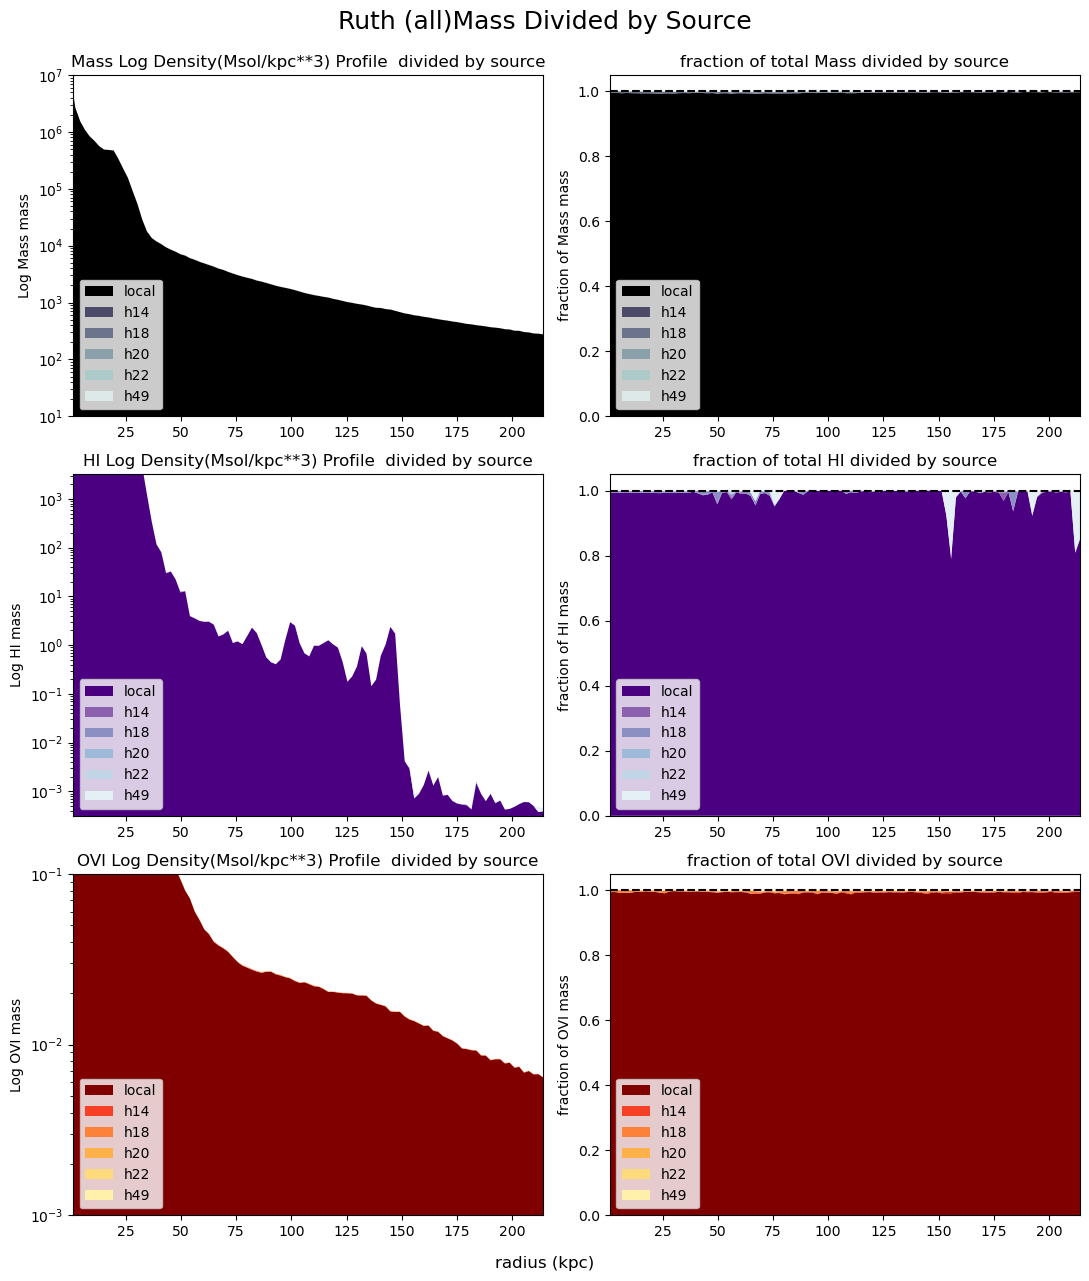

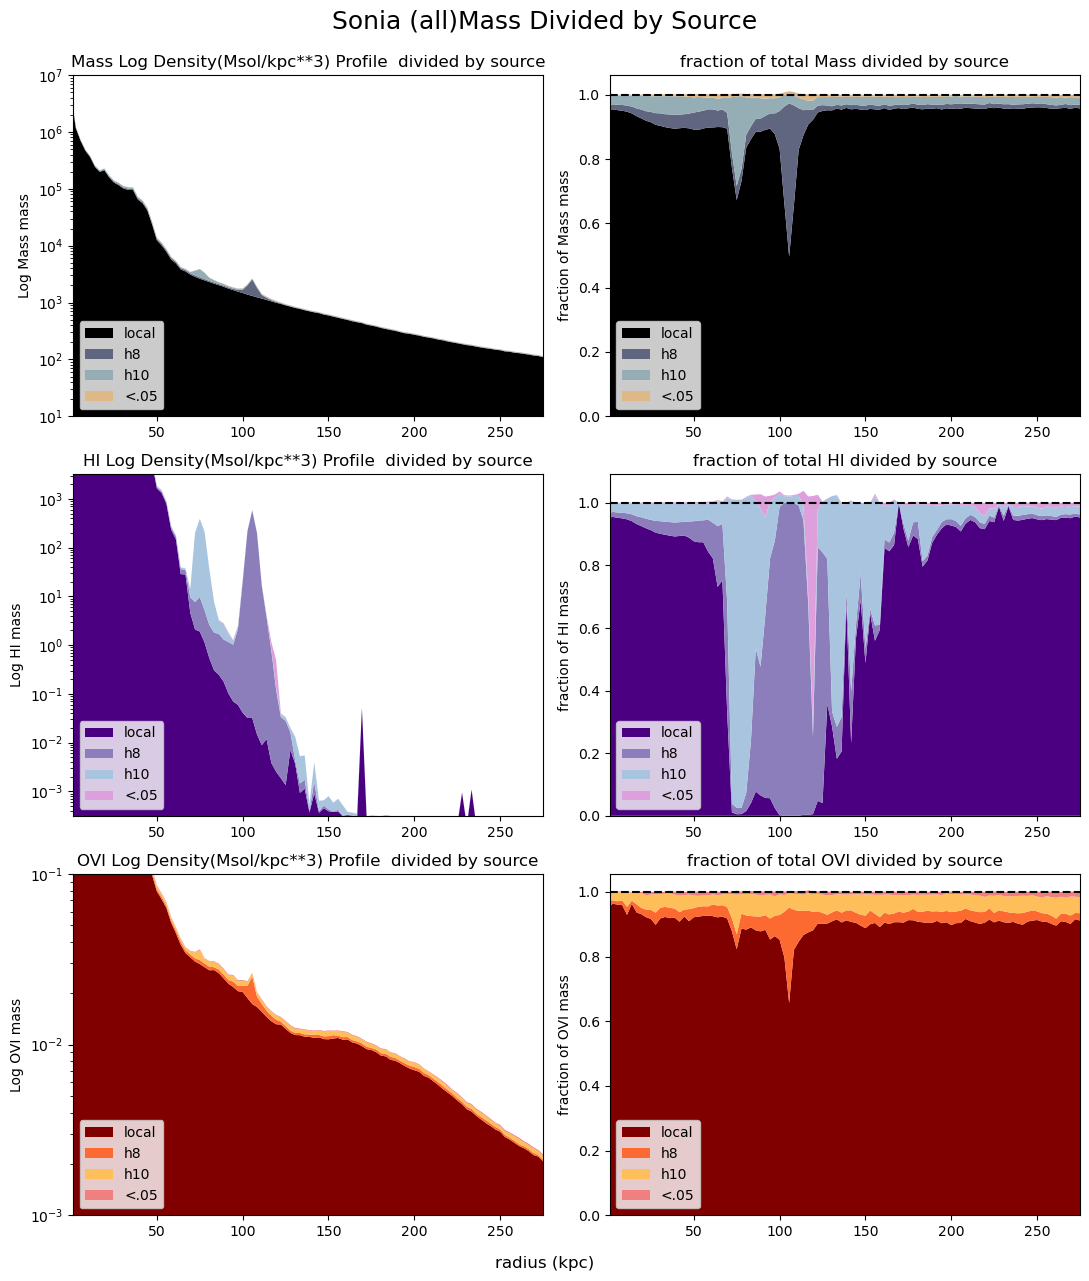

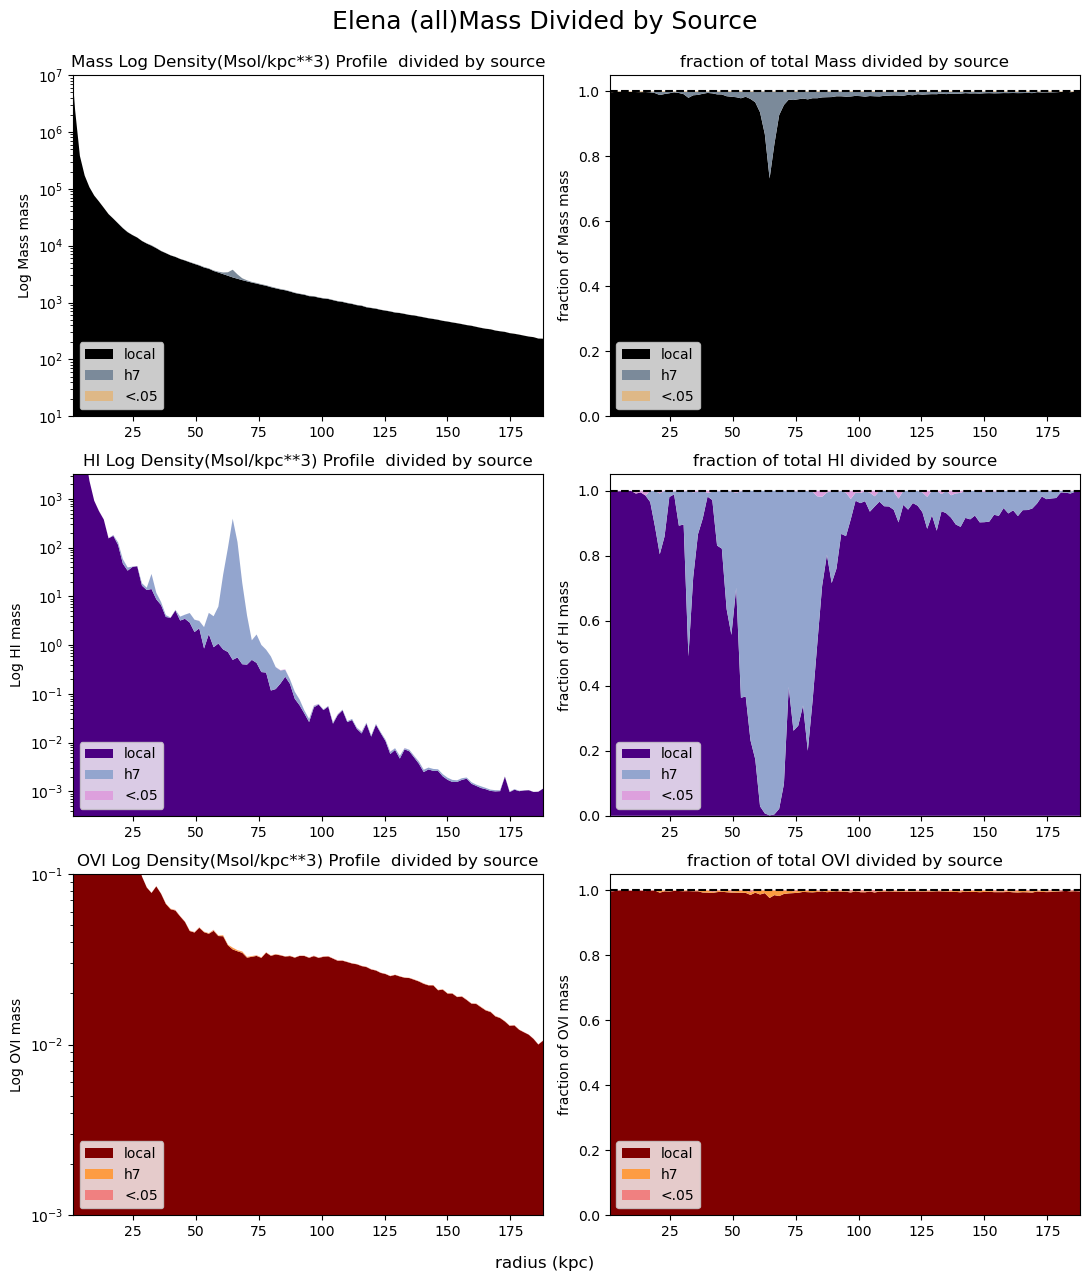

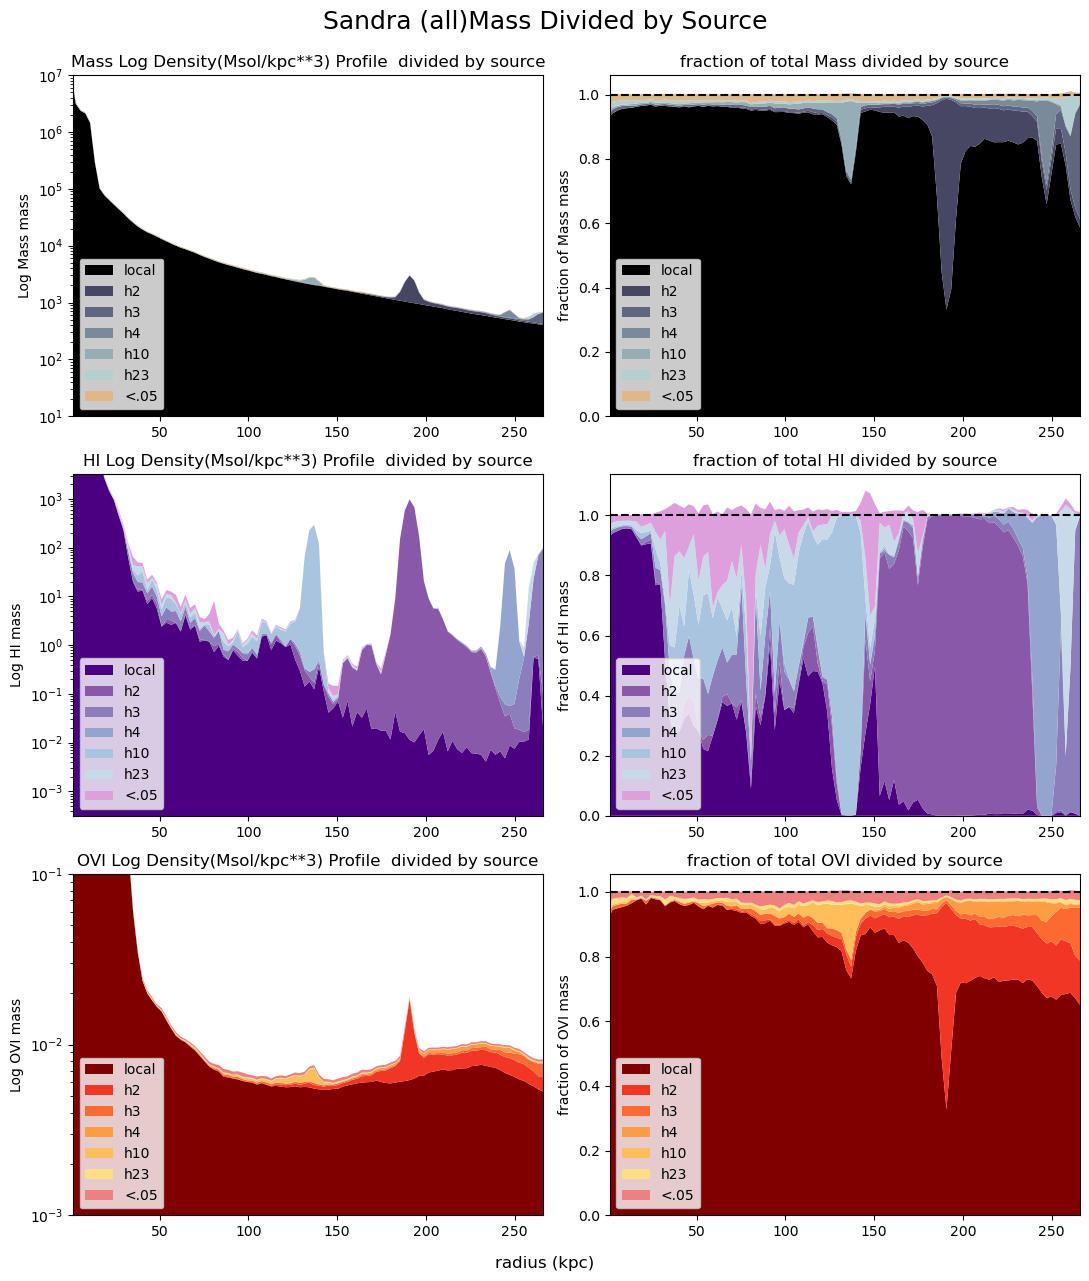

In [55]:
data_filepath  = '/home/vadilloj/MAP2023/Vadillo-Justice-League-Code/MassFracs-Divided-By-Source-c/Data/'
filenames  = [  'Ruth','Sonia',  'Elena', 'Sandra']
readin = True
for filename in filenames:
    edge = int(simulations.at[filename, 'Rvir'])
    if readin:
        
        HaloChars = readInData(filename)
        if '<.05' in list(HaloChars.index):
            group = True
        else:
            group = False
    else:

        s, h1, h = base.load_in_sim(filename, return_h = True)
        ions.calculate_gas_mass(s)
        subsims = tracking.find_halo_particles(h1, filename)##returns a dictionary of subsims for all halos in the simulations, 
        #accesible by their halo number (ie h2, h10 etc)
        if filename == 'Ruth':
            HaloChars, group = getHaloChars(h1, subsims,edge, False)
        else:
            HaloChars, group = getHaloChars(h1, subsims,edge)
    
        

        data_name = data_filepath + filename +"Halo Charachteristics.csv"
        HaloChars.to_csv(data_name)
    try:
        sHaloChars = HaloChars.drop('halos')
    except KeyError:
        sHaloChars = HaloChars
        pass
    make_all_stacks(sHaloChars, filename,edge ,group )

In [20]:
simulations

,gal num,filepath,Halo keys,mass,mstar,mgas,Rvir,nSats,HI_mass,OVI_mass,sat_mass_frac,sat_HI_frac,sat_OVI_frac
Sandra,h148,/home/vadilloj/MAP2023/Sims/h148.cosmo50PLK.30...,"[np.str_('h148_2'), np.str_('h148_3'), np.str_...",2.052077e+12,1.917510e+11,1.527100e+11,266.215150,16.0,1.414185e+10,2.609339e+06,0.009316,0.337959,0.098410
Ruth,h229,/home/vadilloj/MAP2023/Sims/h229.cosmo50PLK.30...,"[np.str_('h229_14'), np.str_('h229_18'), np.st...",1.052426e+12,1.020237e+11,7.695528e+10,214.442995,5.0,1.862303e+10,1.403408e+06,0.000414,0.006439,0.006718
Sonia,h242,/home/vadilloj/MAP2023/Sims/h242.cosmo50PLK.30...,"[np.str_('h242_8'), np.str_('h242_10'), np.str...",1.150238e+12,8.973881e+10,9.158841e+10,275.603382,7.0,2.162918e+10,1.155743e+06,0.007511,0.112475,0.085670
Elena,h329,/home/vadilloj/MAP2023/Sims/h329.cosmo50PLK.30...,"[np.str_('h329_7'), np.str_('h329_29'), np.str...",7.104449e+11,8.991782e+10,2.673112e+10,188.010756,3.0,6.212192e+08,7.602241e+05,0.000727,0.114009,0.004595


In [ ]:
sHaloChars

In [ ]:
subsims = tracking.find_halo_particles(h1, simulations, filename, groupSmalls = True)##returns a dictionary of subsims for all halos in the simulations, 